# Explore here

In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.preprocessing import image
import tensorflow as tf

I0000 00:00:1775833759.870996    1589 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775833778.106734    1589 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775833792.150472    1589 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
import os
import shutil

ruta_real_datos = '/workspaces/Clasificador-de-Imagenes./data/raw/dogs-vs-cats/train'

def split_train_folder_final(train_path):
    if not os.path.exists(train_path):
        print(f"❌ La ruta no existe: {train_path}")
        return

    dogs_folder = os.path.join(train_path, 'dogs')
    cats_folder = os.path.join(train_path, 'cats')

    os.makedirs(dogs_folder, exist_ok=True)
    os.makedirs(cats_folder, exist_ok=True)

    # Listamos los archivos
    archivos = os.listdir(train_path)

    count = 0
    for filename in archivos:
        old_path = os.path.join(train_path, filename)

        # Saltamos si es una carpeta (para no mover 'dogs' o 'cats')
        if os.path.isdir(old_path):
            continue

        name_lower = filename.lower()
        
        # En tus archivos el nombre es 'cat.3431.jpg', así que 'startswith' funciona perfecto
        if name_lower.startswith('dog'):
            shutil.move(old_path, os.path.join(dogs_folder, filename))
            count += 1
        elif name_lower.startswith('cat'):
            shutil.move(old_path, os.path.join(cats_folder, filename))
            count += 1
        
        # Imprimir progreso cada 5000 archivos para no saturar la consola
        if count % 5000 == 0 and count > 0:
            print(f"✔ Procesados {count} archivos...")


# EJECUTAR AHORA
split_train_folder_final(ruta_real_datos)

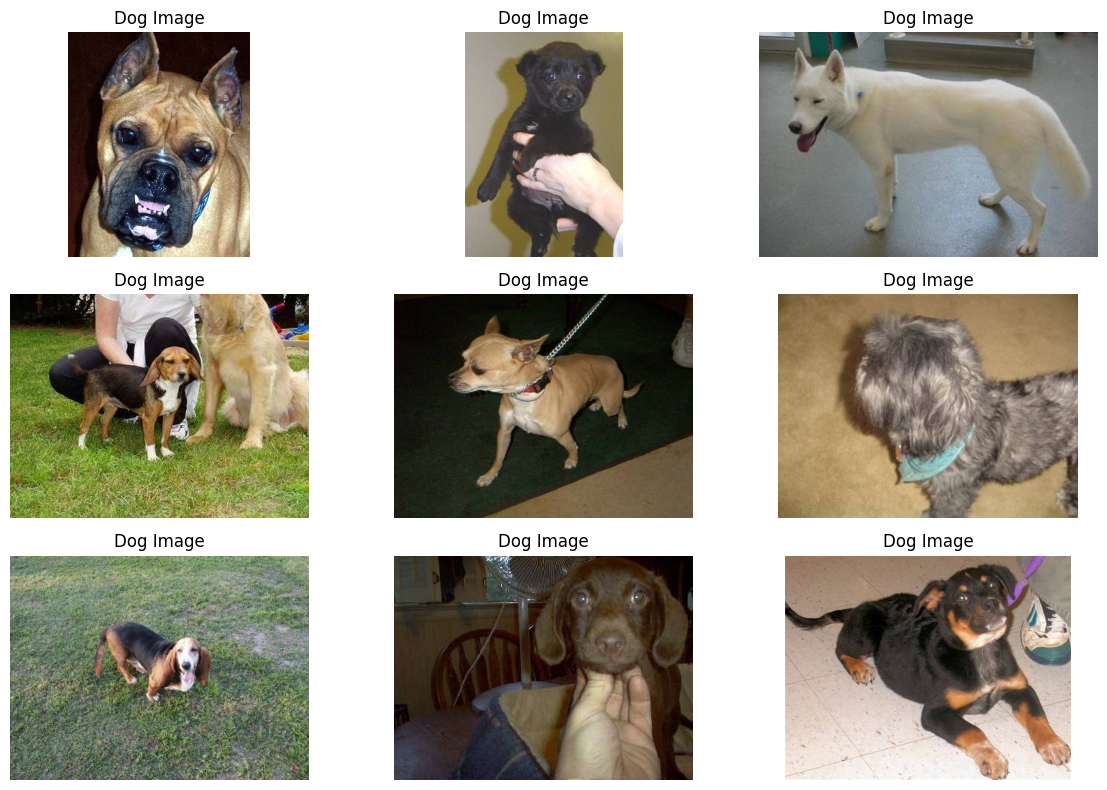

In [3]:
# Importar y comprobar las 9 primeras imágenes de perros

# Ruta al directorio que contiene sus datos de imagen
data_dir = "../data/raw/dogs-vs-cats/train"

# Obtener una lista de todos los nombres de archivos de imágenes de perros
dog_subfolder = os.path.join(data_dir, "dogs")

# Obtener una lista de todos los nombres de archivos de imágenes de perros
dog_image_files = os.listdir(dog_subfolder)

# Cargar las nueve primeras imágenes de perros
dog_images = []
for i in range(9):
    img_path = os.path.join(dog_subfolder, dog_image_files[i])
    img = image.load_img(img_path)  # Ajuste target_size según sea necesario
    img_array = image.img_to_array(img)
    img_array /= 255.0  # Normalice los valores de los píxeles a [0, 1].
    dog_images.append(img_array)

# Cree una única figura para mostrar las nueve imágenes
plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(dog_images[i])
    plt.title('Dog Image')
    plt.axis('off')

# Ajustar el diseño
plt.tight_layout()

# Mostrar las imágenes
plt.show()


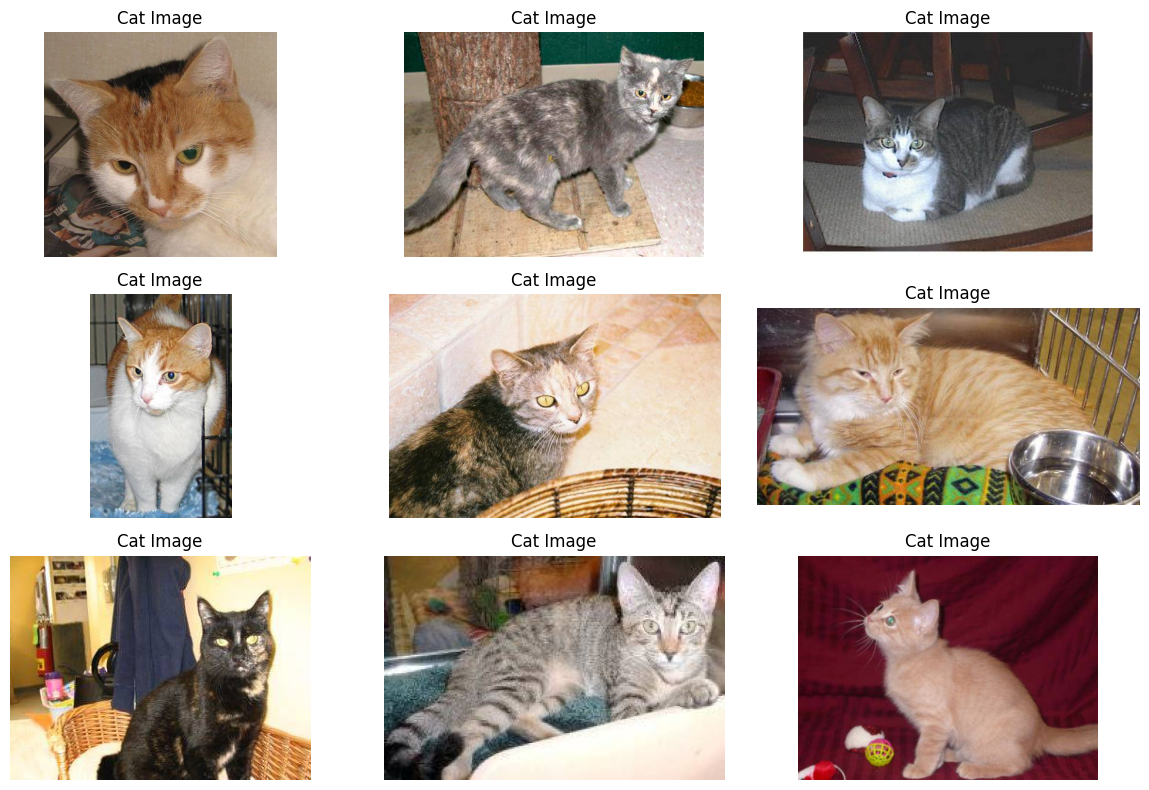

In [4]:
# Importar y comprobar las 9 primeras imágenes de gatos

# Ruta al directorio que contiene sus datos de imagen
data_dir = "../data/raw/dogs-vs-cats/train"

# Obtener una lista de todos los nombres de archivos de imagen Cat
cats_subfolder = os.path.join(data_dir, "cats")

# Obtener una lista de todos los nombres de archivos de imagen Cat
cats_image_files = os.listdir(cats_subfolder)

# Cargar las nueve primeras imágenes de gato
cats_images = []
for i in range(min(9, len(cats_image_files))):  # Limitar a las imágenes de gato disponibles
    img_path = os.path.join(cats_subfolder, cats_image_files[i])
    img = image.load_img(img_path)
    img_array = image.img_to_array(img)
    img_array /= 255.0
    cats_images.append(img_array)

# Crear una única figura para mostrar todas las imágenes cat
plt.figure(figsize=(12, 8))

for i in range(len(cats_images)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(cats_images[i])
    plt.title('Cat Image')
    plt.axis('off')

# Ajustar el diseño
plt.tight_layout()

# Mostrar las imágenes
plt.show()


In [5]:
import tensorflow as tf

# Definir la ruta (asegúrate de que esta carpeta contenga las subcarpetas 'dogs' y 'cats')
train_dir = "/workspaces/Clasificador-de-Imagenes./data/raw/dogs-vs-cats/train"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(150, 150), # Ajusta al tamaño que necesite tu modelo
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(150, 150),
    batch_size=32
)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.


E0000 00:00:1775833807.996977    1589 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


In [6]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D , Flatten

model = Sequential()
model.add(Conv2D(input_shape = (224,224,3), filters = 64, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 64,kernel_size = (3,3),padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2),strides = (2,2)))

# Mover los datos por las capas densas
model.add(Flatten())
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 4096,activation = "relu"))
model.add(Dense(units = 2, activation = "softmax"))

/home/vscode/.local/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1775833809.388381    1589 cpu_allocator_impl.cc:82] Allocation of 411041792 exceeds 10% of free system memory.
W0000 00:00:1775833810.436432    1589 cpu_allocator_impl.cc:82] Allocation of 411041792 exceeds 10% of free system memory.
W0000 00:00:1775833810.808568    1589 cpu_allocator_impl.cc:82] Allocation of 411041792 exceeds 10% of free system memory.


W0000 00:00:1775833811.256932    1589 cpu_allocator_impl.cc:82] Allocation of 67108864 exceeds 10% of free system memory.
W0000 00:00:1775833811.350140    1589 cpu_allocator_impl.cc:82] Allocation of 67108864 exceeds 10% of free system memory.


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

# --- Configuración de Tamaño ---
IMG_SIZE = (200, 200) 
BATCH_SIZE = 16  

# 1. Cargar los datos con el nuevo tamaño
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,  
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,  
    batch_size=BATCH_SIZE
)

# 2. Definir el modelo para recibir 200x200
model = models.Sequential([
   
    layers.Input(shape=(200, 200, 3)), 
    
    layers.Rescaling(1./255),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid') 
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 3. Entrenar el modelo
# Nota: Si se queda trabado, es por la falta de GPU, pero eventualmente avanzará.
model.fit(train_ds, validation_data=val_ds, epochs=1)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.


 125/1250 ━━━━━━━━━━━━━━━━━━━━ 22:33 1s/step - accuracy: 0.4854 - loss: 0.9320

KeyboardInterrupt: 

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("../models/vgg16_1.h5", monitor = "val_accuracy", verbose = 1, save_best_only = True, save_weights_only = False, mode = "auto")
early = EarlyStopping(monitor = "val_accuracy", patience = 3, verbose = 1, mode = "auto")
hist = model.fit(train_ds, steps_per_epoch = 100, validation_data = val_ds, validation_steps = 10, epochs = 3, callbacks = [checkpoint, early])

Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.7504 - loss: 0.5171
Epoch 1: val_accuracy improved from None to 0.69375, saving model to ../models/vgg16_1.h5



Epoch 1: finished saving model to ../models/vgg16_1.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 78s 779ms/step - accuracy: 0.7475 - loss: 0.5214 - val_accuracy: 0.6938 - val_loss: 0.5672
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.6891 - loss: 0.5766
Epoch 2: val_accuracy improved from 0.69375 to 0.75000, saving model to ../models/vgg16_1.h5



Epoch 2: finished saving model to ../models/vgg16_1.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 82s 823ms/step - accuracy: 0.7256 - loss: 0.5406 - val_accuracy: 0.7500 - val_loss: 0.5456
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 923ms/step - accuracy: 0.7476 - loss: 0.5094
Epoch 3: val_accuracy improved from 0.75000 to 0.75625, saving model to ../models/vgg16_1.h5



Epoch 3: finished saving model to ../models/vgg16_1.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.7563 - loss: 0.5029 - val_accuracy: 0.7563 - val_loss: 0.5405


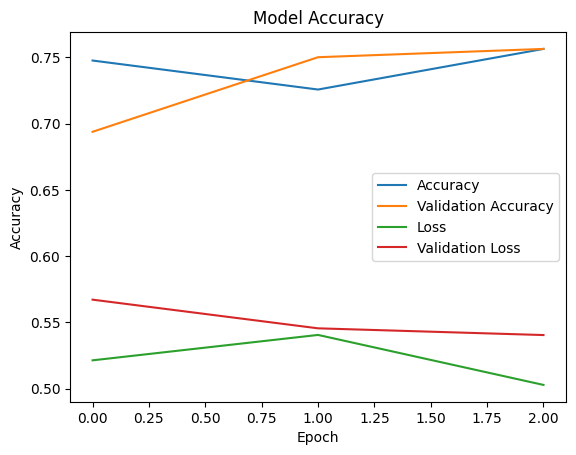

In [ ]:
# Comprobar la exactitud de los datos

# Trazar los resultados
plt.plot(hist.history["accuracy"])
plt.plot(hist.history["val_accuracy"])
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])

# Configurar el diseño del gráfico
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy", "Validation Accuracy", "Loss", "Validation Loss"])

# Trazar
plt.show()

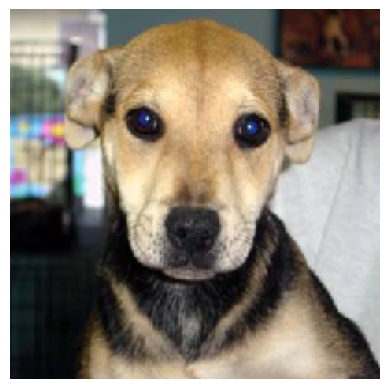

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
Predicción: CAT 


In [ ]:
from tensorflow.keras.models import load_model

img_path = "/workspaces/Clasificador-de-Imagenes./data/raw/dogs-vs-cats/train/dogs/dog.4.jpg"
img = image.load_img(img_path, target_size=(200, 200))

# 2. Visualización
plt.imshow(img)
plt.axis('off')
plt.show()

img_array = image.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)

# 4. Cargar modelo y predecir
saved_model = load_model("../models/vgg16_1.h5")
output = saved_model.predict(img_batch)

if output[0][0] < 0.5:
    print(f"Predicción: CAT ")
else:
    print(f"Predicción: DOG ")

Conclusiones: El modelo es en un 75% predictivo a la hora de determinar si una imagen es un perro o un gato.